### Logic flow
* load pseudopopulation all_neurs_info_df, trial tables, epoch spikes/FRs
* all plots & tests below just slice the stacked arrays per patient (columns) or per condition (rows)
* Visualize spikes and FRs
    * raster+PSTH across 1st & 2nd halves of every trial
    * raster+PSTH across stim_epoch, colored by context (orangered/grey/deepskyblue)
    * raster+PSTH across stim_epoch, 1 subplot per context, colored by stimulus quartiles
    * line plot of stim vs FR during stim_epoch, binned by counts
    * Heatmap of stim vs FR during stim_epoch across all neurons; subplotted per context
        * each neuron is z-scored across trials WITHIN the context
* Encoding tests: per neuron x context, Kruskal-Wallis on spike counts (curv vs flat), FDR per context
* raster+PSTH for significant neurons

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from utils import plot_style, norm01; plot_style('notebook');
import scipy.stats as stats
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.multitest import fdrcorrection

In [2]:
pseudopop_dir = '../../outputs/processed_data/pseudopop'; figs_dir = '../../outputs/figs/single_units'

conds = ['C1','C2','C3']; thresholds = [-.2, 0, .2]; cntxt_colors= ['orangered', 'gray', 'deepskyblue']
epoch = 'stim'; normFR = False
size, dt = .02, .01 # smoothing params (trial-half extraction below re-bins from raw spike times)

all_neurs_info_df = pd.read_parquet(f'{pseudopop_dir}/all_neurs_info_df.parquet')
# pseudopop rows are in trial_key order (neur3), so each patient's trial table is just its csv slice sorted by trial_key
all_beh_trials_df = pd.read_csv('../../data/psychopy/all_beh_trials_df.csv'); patients = sorted(all_beh_trials_df.loc[all_beh_trials_df['eligibility'] == 'neuronal', 'subj'].unique())
pt_beh_trials_dfs = {patient: all_beh_trials_df.loc[all_beh_trials_df['subj'] == patient].sort_values('trial_key').reset_index(drop=True) for patient in patients}
print(f'patients: {patients}, {len(all_neurs_info_df)} neurons total')

# figs saved straight to disk (not shown inline): one folder per plot type; per-context plots get a pt subfolder holding C1/C2/C3.png
for sub in ['rasters_PSTH_across_trial', 'rasters_PSTH_stimEpoch_context-tuning', 'heatmap_stimEpoch_stim-tuning-per-context', 'heatmap_unnormed_stimEpoch_stim-tuning-per-context']: os.makedirs(f'{figs_dir}/{sub}', exist_ok=True)
for sub in ['rasters_PSTH_stimEpoch_stim-tuning-per-context', 'lineplot_stimEpoch_stim-tuning-per-context']:
    for patient in patients: os.makedirs(f'{figs_dir}/{sub}/pt{int(patient)}', exist_ok=True)

# stacked epoch arrays: rows = trials, cols = all neurons across patients
spikes      = np.load(f'{pseudopop_dir}/{epoch}/spikes.npy', allow_pickle=True)
FRs         = np.load(f'{pseudopop_dir}/{epoch}/FRs.npy', allow_pickle=True)
bin_centers = np.load(f'{pseudopop_dir}/{epoch}/bin_centers.npy', allow_pickle=True)
base_spikes = np.load(f'{pseudopop_dir}/baseline/spikes.npy', allow_pickle=True)
base_FRs    = np.load(f'{pseudopop_dir}/baseline/FRs.npy', allow_pickle=True)
trial_mean_FR = np.load(f'{pseudopop_dir}/{epoch}/trial_mean_FRs.npy', allow_pickle=True)

def get_normed_FRs(FRs, base_FRs):
    return FRs - base_FRs.mean(axis=(0, 2), keepdims=True) # trial-avged baseline, (neurons, 1)

def get_pt_slice(patient):
    ''' stacked-matrix columns + neuron metadata for one patient '''
    pt_mask = (all_neurs_info_df['patient'] == int(patient)).values
    return all_neurs_info_df.loc[pt_mask, 'col_idx'].values, all_neurs_info_df.loc[pt_mask].reset_index(drop=True)

patients: [np.float64(2512.0), np.float64(2518.0), np.float64(2521.0), np.float64(2522.0), np.float64(2605.0)], 64 neurons total


### visualization 1: example baseline trials + example stim raster

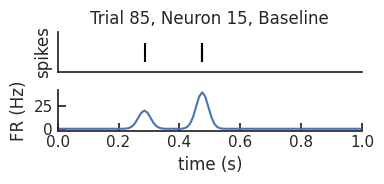

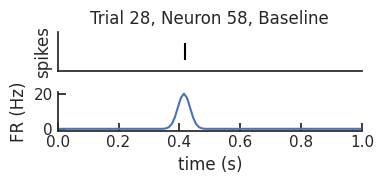

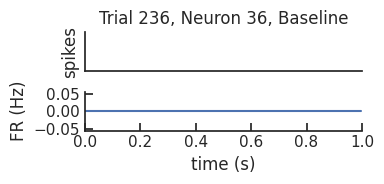

In [3]:
n_trials, n_all_neurs = base_spikes.shape
for _ in range(3):

    rand_trial_idx, rand_neur_idx = np.random.randint(0, n_trials), np.random.randint(0, n_all_neurs)

    fig, ax = plt.subplots(2, 1, figsize=(4,2), sharex=True)

    trial_spikes = base_spikes[rand_trial_idx, rand_neur_idx]
    ax[0].set(title=f"Trial {rand_trial_idx}, Neuron {rand_neur_idx}, Baseline", ylabel="spikes", yticks=[])
    ax[0].tick_params(axis='both', bottom=False, labelbottom=False)
    ax[0].eventplot(trial_spikes, colors='black', lineoffsets=0, linelengths=0.8)

    base_bin_centers = np.load(f'{pseudopop_dir}/baseline/bin_centers.npy', allow_pickle=True)
    fr = base_FRs[rand_trial_idx, rand_neur_idx]
    ax[1].set(xlabel="time (s)", xlim=(0, 1), ylabel="FR (Hz)")
    ax[1].plot(base_bin_centers, fr)

    plt.tight_layout()
    plt.show()

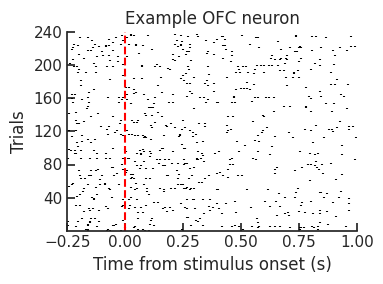

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))
neur_idx = 1; neur_region = all_neurs_info_df['region'].iloc[neur_idx]
ax.set(title = f'Example {neur_region[2:-1]} neuron', ylabel='Trials', xlabel='Time from stimulus onset (s)', xticks=np.arange(-.25, 1.01, .25), xlim=(-.25,1), ylim=(0,240), yticks=np.arange(40, 241, 40))
ax.eventplot(spikes[:, neur_idx], colors='black', linelengths=0.8)
ax.axvline(0, color='red', linestyle='--')

plt.tight_layout(); plt.show()

### visualization 2: trial halves (per patient; re-extracted from spike times, not part of build epochs)

In [5]:
# trial half prestarts and durations
trial_halves = ['pre-choice, stim-anchored', 'post-choice, outcome-anchored']
trial_half_prestarts = {'pre-choice, stim-anchored': -.25, 'post-choice, outcome-anchored': -1.25}
trial_half_durs      = {'pre-choice, stim-anchored': 3.5,  'post-choice, outcome-anchored': 1.0}

def get_trial_half_spikes_and_FRs(neur_trigs_df, neurs_info_df, trial_half, size=size, dt=dt):
    ''' spikes + smoothed FRs (Hz) for all trials, aligned to a trial half's onset
        pre-choice aligned to stim onset, post-choice aligned to outcome (anticipation) onset '''

    prestart, dur = trial_half_prestarts[trial_half], trial_half_durs[trial_half]
    bin_edges = np.arange(prestart, dur + dt, dt); half_bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2; n_bins = len(bin_edges) - 1

    anchor_event = 'stim started' if trial_half == trial_halves[0] else 'anticipation started'
    anchor_times = neur_trigs_df.loc[neur_trigs_df['event'] == anchor_event, 'aligned_time'].values

    trial_neur_spikes, trial_neur_FRs = np.empty((len(anchor_times), len(neurs_info_df)), dtype=object), np.zeros((len(anchor_times), len(neurs_info_df), n_bins))
    for trial_idx, t0 in enumerate(anchor_times):
        for neur_idx, (_, neur_row) in enumerate(neurs_info_df.iterrows()):
            s = neur_row['spikes']
            s = s[(s >= t0 + prestart) & (s <= t0 + dur)] - t0
            counts, _ = np.histogram(s, bins=bin_edges)
            smooth = gaussian_filter1d(counts.astype(float), sigma=size/dt, mode='reflect', truncate=3.0) / dt
            trial_neur_spikes[trial_idx, neur_idx] = s
            trial_neur_FRs[trial_idx, neur_idx, :] = smooth

    return trial_neur_spikes, trial_neur_FRs, half_bin_centers

# epoch-name annotations placed below the x-axis, per trial half column (x position, label)
half_epoch_labels = [
    [(0.5, 'Stim'), (1.75, 'Delay'), (3.0, 'Resp')],       # pre-choice, stim-anchored
    [(-.75, 'Resp'), (.5, 'Outcome')],                     # post-choice, outcome-anchored
]

for patient in patients:
    fig_path = f'{figs_dir}/rasters_PSTH_across_trial/pt{int(patient)}.png'
    if os.path.exists(fig_path): print(f'{fig_path} already exists, skipping'); continue

    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    neur_trigs_df = pd.read_parquet(f'../../outputs/processed_data/20{int(patient)}/neur_trigs_df.parquet')
    trial_half_data = {th: get_trial_half_spikes_and_FRs(neur_trigs_df, pt_neurs_info_df, th) for th in trial_halves}
    n_neurs = len(pt_neurs_info_df)

    fig, axs = plt.subplots(n_neurs, 2, figsize=(11, n_neurs * 3))
    if n_neurs == 1: axs = axs[np.newaxis, :]

    for neur_id in range(n_neurs):
        for col, trial_half in enumerate(trial_halves):

            half_spikes, half_FRs, half_bin_centers = trial_half_data[trial_half]
            n_trials_half = half_spikes.shape[0]
            if normFR: half_FRs, ylab = get_normed_FRs(half_FRs, base_FRs[:, pt_cols]), 'norm. FR (Hz)'
            else: half_FRs, ylab = half_FRs.copy(), 'FR (Hz)'

            # placeholder to be replaced with 2 stacked axes
            ss = axs[neur_id, col].get_subplotspec(); axs[neur_id, col].remove()
            gs = ss.subgridspec(2, 1, height_ratios=[1, 1], hspace=0)
            ax_raster = fig.add_subplot(gs[0]); ax_psth = fig.add_subplot(gs[1], sharex=ax_raster)

            ax_raster.eventplot(half_spikes[:, neur_id], colors='k', lineoffsets=np.arange(n_trials_half), linelengths=5.0, linewidths=1.0)
            ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            align_lab = 'stim onset' if col == 0 else 'outcome onset'
            ax_raster.set(title=f"{pt_neurs_info_df['region'].iloc[neur_id]}, Neuron {neur_id} ({align_lab})")

            data = half_FRs[:, neur_id, :]
            mu, sderr = data.mean(axis=0), data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
            ax_psth.plot(half_bin_centers, mu, color='k', linewidth=1)
            ax_psth.fill_between(half_bin_centers, mu - sderr, mu + sderr, color='0.7', alpha=0.5, linewidth=0)

            # trial half onset/boundary markers
            for ax in (ax_raster, ax_psth): ax.axvline(0, color='k', linestyle='--', alpha=.5)
            if col == 0:
                for ax in (ax_raster, ax_psth):
                    ax.axvline(1, color='k', linestyle='--', alpha=.5)    # end of delay
                    ax.axvline(2.5, color='k', linestyle='--', alpha=.5)  # end of response
            else:
                for ax in (ax_raster, ax_psth): ax.axvline(-.25, color='k', linestyle='--', alpha=.5)
                ax_psth.set_xticks(np.arange(-1.0, 1.01, .5))  # reduce tick frequency (was every .25)

            ax_psth.set(xlim=(half_bin_centers[0], half_bin_centers[-1]), ylabel=ylab)
            ax_psth.set_xlabel('Time (s)', labelpad=20)  # push below the epoch-name row so they don't collide

            # epoch-name text between the numeric tick labels and the x-axis label (added, not replacing ticks)
            for x, label in half_epoch_labels[col]:
                ax_psth.text(x, -.25, label, transform=ax_psth.get_xaxis_transform(), ha='center', va='top', fontsize=10)

    plt.suptitle(f'Patient {int(patient)}, trial halves', y=1.0, fontsize=14); plt.tight_layout()
    plt.savefig(fig_path); plt.close(fig)

../../outputs/figs/single_units/rasters_PSTH_across_trial/pt2512.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_across_trial/pt2518.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_across_trial/pt2521.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_across_trial/pt2522.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_across_trial/pt2605.png already exists, skipping


### stim epoch: raster+PSTH per neuron, colored by context (per patient)

In [6]:
plot_FRs = get_normed_FRs(FRs, base_FRs); yaxis_lab = 'norm. '  # stim epoch normed by trial-avged baseline

for patient in patients:
    fig_path = f'{figs_dir}/rasters_PSTH_stimEpoch_context-tuning/pt{int(patient)}.png'
    if os.path.exists(fig_path): print(f'{fig_path} already exists, skipping'); continue

    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    pt_beh_trials_df = pt_beh_trials_dfs[patient]
    pt_spikes, pt_FRs = spikes[:, pt_cols], plot_FRs[:, pt_cols]
    n_trials, n_neurs = pt_FRs.shape[0], pt_FRs.shape[1]

    # color each trial by its context (orangered/gray/deepskyblue)
    trial_colors = pt_beh_trials_df['context'].map(dict(zip(conds, cntxt_colors))).values

    n_cols = 3; n_rows = int(np.ceil(n_neurs / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3)); axs, ax = axs.flatten(), 0
    first_psth_ax = None

    for neur_id in range(n_neurs):

        if ax >= len(axs): break

        # placeholder to be replaced with 2 stacked axes
        ss = axs[ax].get_subplotspec(); axs[ax].remove()
        gs = ss.subgridspec(2, 1, height_ratios=[1, 1], hspace=0)
        ax_raster = fig.add_subplot(gs[0]); ax_psth = fig.add_subplot(gs[1], sharex=ax_raster)
        if first_psth_ax is None: first_psth_ax = ax_psth

        ax_raster.eventplot(pt_spikes[:, neur_id], colors=trial_colors, lineoffsets=np.arange(n_trials), linelengths=5.0, linewidths=1.0)
        ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        ax_raster.axvline(0, color='red', linestyle='--')
        ax_raster.set(title=f"{pt_neurs_info_df['region'].iloc[neur_id]}, Neuron {neur_id}")

        # psth — mean ± sem per context
        for cond, cntxt_color in zip(conds, cntxt_colors):
            cond_ids = pt_beh_trials_df.index[pt_beh_trials_df['context'] == cond]
            data = pt_FRs[cond_ids, neur_id, :]
            mu, sderr = data.mean(axis=0), data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
            ax_psth.plot(bin_centers, mu, color=cntxt_color, label=cond, linewidth=1)
            ax_psth.fill_between(bin_centers, mu - sderr, mu + sderr, color=cntxt_color, alpha=.2, linewidth=0)
        ax_psth.axvline(0, color='red', linestyle='--')
        ax_psth.set(xlim=(bin_centers[0], bin_centers[-1]),ylabel=f"{yaxis_lab}FR (Hz)", xlabel=f"Time (s)")

        ax += 1

    first_psth_ax.legend(loc='lower right', fontsize=7)
    plt.suptitle(f'Patient {int(patient)}, {epoch} epoch', y=1.0, fontsize=14); plt.tight_layout()
    plt.savefig(fig_path); plt.close(fig)

../../outputs/figs/single_units/rasters_PSTH_stimEpoch_context-tuning/pt2512.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_context-tuning/pt2518.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_context-tuning/pt2521.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_context-tuning/pt2522.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_context-tuning/pt2605.png already exists, skipping


### Bin by position: raster+PSTH per context, colored by stimulus buckets (per patient)

In [7]:
norm = False; n_contrast_bins = 4
shared_contrast_edges = np.linspace(-.4, .4, n_contrast_bins + 1)  # fixed, equal-width edges shared across conditions -> a given true_stim always lands in the same bucket

for patient in patients:
    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    pt_beh_trials_df = pt_beh_trials_dfs[patient]
    pt_spikes = spikes[:, pt_cols]
    if norm: pt_FRs, yaxis_lab = get_normed_FRs(FRs, base_FRs)[:, pt_cols], 'norm. '
    else: pt_FRs, yaxis_lab = FRs[:, pt_cols], ''
    n_trials, n_neurs = pt_FRs.shape[0], pt_FRs.shape[1]

    for i, cond in enumerate(conds):
        fig_path = f'{figs_dir}/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt{int(patient)}/{cond}.png'
        if os.path.exists(fig_path): print(f'{fig_path} already exists, skipping'); continue

        cond_beh_trials_df = pt_beh_trials_df[pt_beh_trials_df['context'] == cond]

        stim_bins   = pd.cut(cond_beh_trials_df['true_stim'], bins=shared_contrast_edges)
        cont_trials = [cond_beh_trials_df.index[stim_bins == cat] for cat in stim_bins.cat.categories]
        cont_labels = [f'{cat.left:.2f} to {cat.right:.2f}' for cat in stim_bins.cat.categories]
        colors      = plt.cm.coolwarm(np.linspace(0, 1, n_contrast_bins))

        n_cols = 3; n_rows = int(np.ceil(n_neurs / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3)); axs, ax = axs.flatten(), 0
        first_psth_ax = None

        for neur_id in range(n_neurs):

            if ax >= len(axs): break

            # placeholder to be replaced with 2 stacked axes
            ss = axs[ax].get_subplotspec(); axs[ax].remove()
            gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
            ax_raster = fig.add_subplot(gs[0]); ax_psth = fig.add_subplot(gs[1], sharex=ax_raster)
            if first_psth_ax is None: first_psth_ax = ax_psth

            # raster — trials sorted and colored by contrast group; one scatter call per group (not per trial)
            trial_counter = 0
            for grp, grp_color in list(zip(cont_trials, colors))[::-1]:
                if len(grp) == 0: continue  # bucket empty for this condition -> skip
                xs, ys = [], []
                for trial_idx in grp:
                    st = pt_spikes[trial_idx, neur_id]
                    xs.append(st); ys.append(np.full_like(st, trial_counter))
                    trial_counter += 1
                ax_raster.scatter(np.concatenate(xs), np.concatenate(ys), s=3, color=grp_color, alpha=.7)
            ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            ax_raster.axvline(0, color='black', linestyle='--')
            ax_raster.set(title=f"{pt_neurs_info_df['region'].iloc[neur_id]}, Neuron {neur_id}", ylabel='Sorted trials')

            # psth — mean ± sem per group
            for grp, grp_label, grp_color in zip(cont_trials, cont_labels, colors):
                if len(grp) == 0: continue  # bucket empty for this condition -> skip
                data = pt_FRs[list(grp), neur_id, :]
                mu = data.mean(axis=0)
                sderr = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
                ax_psth.plot(bin_centers, mu, color=grp_color, alpha=.9, label=grp_label)
                ax_psth.fill_between(bin_centers, mu - sderr, mu + sderr, color=grp_color, alpha=.2, linewidth=0)
            ax_psth.axvline(0, color='black', linestyle='--')
            ax_psth.set(xlim=(bin_centers[0], bin_centers[-1]), xticks=np.linspace(-.25,1,6), ylabel='FR (Hz)', xlabel='Time (s)')

            ax += 1

        first_psth_ax.legend(loc='lower right', fontsize=7)
        plt.suptitle(f'Shape modulation, pt{int(patient)}, Context {cond}, {epoch} epoch', y=1.0, fontsize=14); plt.tight_layout()
        plt.savefig(fig_path); plt.close(fig)

../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2512/C1.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2512/C2.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2512/C3.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2518/C1.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2518/C2.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2518/C3.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2521/C1.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_stim-tuning-per-context/pt2521/C2.png already exists, skipping
../../outputs/figs/single_units/rasters_PSTH_stimEpoch_s

### Bin by count: verify stim counts per bucket (lineplot left commented)

In [8]:
def equal_count_edges(shape_positions, target_n=8):
    ''' bin edges that pool adjacent, actually-observed stim positions (0-count positions are
        skipped since np.unique never returns them) until each bucket holds >= target_n trials '''
    vals, counts = np.unique(shape_positions, return_counts=True)
    step = np.diff(vals).min()
    edges, running = [vals[0] - step / 2], 0
    for v, c in zip(vals, counts):
        running += c
        if running >= target_n:
            edges.append(v + step / 2)
            running = 0
    return np.array(edges)

for patient in patients:
    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    pt_beh_trials_df = pt_beh_trials_dfs[patient]
    if norm: pt_trial_mean_FR, yaxis_lab = get_normed_FRs(FRs, base_FRs)[:, pt_cols].mean(axis=2), 'norm. '
    else: pt_trial_mean_FR, yaxis_lab = trial_mean_FR[:, pt_cols], ''
    n_neurs = len(pt_neurs_info_df)
    print(f'===== pt{int(patient)} =====')
    for i, cond in enumerate(conds):
        cond_ids        = pt_beh_trials_df.index[pt_beh_trials_df['context'] == cond]
        shape_positions = pt_beh_trials_df.loc[cond_ids, 'true_stim']

        cond_edges   = equal_count_edges(shape_positions)
        shape_bins   = pd.cut(shape_positions, bins=cond_edges)
        shape_trials = [shape_bins.index[shape_bins == cat] for cat in shape_bins.cat.categories]
        bucket_x     = np.array([cat.mid for cat in shape_bins.cat.categories])
        trial_x      = bucket_x[shape_bins.cat.codes.values]

        print(f'--- {cond}, n_trials={len(cond_ids)} ---')
        for cat, trials in zip(shape_bins.cat.categories, shape_trials): print(f'  {cat.mid:6.2f} ({cat.left:.2f} to {cat.right:.2f}): n={len(trials)}')
        print()

        fig_path = f'{figs_dir}/lineplot_stimEpoch_stim-tuning-per-context/pt{int(patient)}/{cond}.png'
        if os.path.exists(fig_path): print(f'{fig_path} already exists, skipping'); continue

        n_cols = 3; n_rows = int(np.ceil(n_neurs / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3)); axs, ax = axs.flatten(), 0

        for neur_id in range(n_neurs):

            if ax >= len(axs): break

            cond_FR = pt_trial_mean_FR[cond_ids, neur_id]
            axs[ax].scatter(trial_x + np.random.normal(0, 0.005, size=len(cond_ids)), cond_FR, s=8, color='0.7', alpha=.6) # raw trials

            mu  = [pt_trial_mean_FR[trials, neur_id].mean() if len(trials) else np.nan for trials in shape_trials]  # empty bin -> gap, not a fake 0
            sem = [pt_trial_mean_FR[trials, neur_id].std(ddof=1) / np.sqrt(len(trials)) if len(trials) > 1 else np.nan for trials in shape_trials]
            axs[ax].errorbar(bucket_x, mu, yerr=sem, color=cntxt_colors[i], marker='o', markersize=4, linewidth=1.5)

            axs[ax].axvline(thresholds[i], color=cntxt_colors[i], linestyle='--')
            ymin, ymax = np.percentile(cond_FR, [0, 95])
            axs[ax].set(title=f"{pt_neurs_info_df['region'].iloc[neur_id]}, Neuron {neur_id}", xlabel='Shape', ylabel=f'{yaxis_lab}FR (Hz)', ylim=(-.5, ymax),xlim=(-.4, .4), xticks=np.linspace(-.4, .4, 5))
            ax += 1

        for ax_idx in range(n_neurs, len(axs)):    axs[ax_idx].axis('off')

        plt.suptitle(f'Shape Tuning: pt{int(patient)}, {epoch} epoch, {cond} context', y=1.0, fontsize=14); plt.tight_layout()
        plt.savefig(fig_path); plt.close(fig)

===== pt2512 =====
--- C1, n_trials=80 ---
   -0.38 (-0.40 to -0.36): n=8
   -0.34 (-0.36 to -0.32): n=8
   -0.30 (-0.32 to -0.28): n=8
   -0.26 (-0.28 to -0.24): n=8
   -0.22 (-0.24 to -0.20): n=8
   -0.16 (-0.20 to -0.12): n=8
   -0.08 (-0.12 to -0.04): n=8
    0.00 (-0.04 to 0.04): n=8
    0.08 (0.04 to 0.12): n=8
    0.16 (0.12 to 0.20): n=8

../../outputs/figs/single_units/lineplot_stimEpoch_stim-tuning-per-context/pt2512/C1.png already exists, skipping
--- C2, n_trials=80 ---
   -0.36 (-0.40 to -0.32): n=8
   -0.28 (-0.32 to -0.24): n=8
   -0.20 (-0.24 to -0.16): n=8
   -0.12 (-0.16 to -0.08): n=8
   -0.04 (-0.08 to -0.00): n=8
    0.04 (-0.00 to 0.08): n=8
    0.12 (0.08 to 0.16): n=8
    0.20 (0.16 to 0.24): n=8
    0.28 (0.24 to 0.32): n=8
    0.36 (0.32 to 0.40): n=8

../../outputs/figs/single_units/lineplot_stimEpoch_stim-tuning-per-context/pt2512/C2.png already exists, skipping
--- C3, n_trials=80 ---
   -0.16 (-0.20 to -0.12): n=8
   -0.08 (-0.12 to -0.04): n=8
    0.00 (-

### Bin by position pairs: tuning heatmap per context (per patient)

In [9]:
n_buckets = 10
cond_thresholds = dict(zip(conds, [-.2, 0, .2]))  # C1, C2, C3 threshs
shared_edges = np.linspace(-.4, .4, n_buckets + 1)  # same bins for every panel, not per-condition

cmap = plt.cm.RdBu_r.copy(); cmap.set_bad('black')          # z-scored: diverging around 0; bins with no trials for this condition shown black instead of blending in
cmap_raw = plt.cm.viridis.copy(); cmap_raw.set_bad('white')  # raw Hz: sequential from 0; empty bins white

region_order = ['HIP', 'AMY', 'OFC', 'ACC']  # region[-4:-1]: 'mRAHIP5' / 'mRHIP5' -> 'HIP', 'mLACC2' -> 'ACC'

# two versions: z-scored (each neuron across trials WITHIN the context & fold -> tuning shape, comparable across neurons) and raw Hz (absolute rates)
for zscore in [True, False]:
  for patient in patients:
    fig_path = f'{figs_dir}/heatmap_{"" if zscore else "unnormed_"}stimEpoch_stim-tuning-per-context/pt{int(patient)}.png'
    if os.path.exists(fig_path): print(f'{fig_path} already exists, skipping'); continue

    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    pt_beh_trials_df = pt_beh_trials_dfs[patient]
    pt_trial_mean_FR = trial_mean_FR[:, pt_cols]
    neur_regions = pt_neurs_info_df['region'].str[-4:-1].values
    region_rank = np.array([region_order.index(region) for region in neur_regions])
    n_neurs = len(pt_neurs_info_df)

    # cols = folds: sort rows on fold1, so fold2 is the held-out test of the tuning structure (a sort-by-peak diagonal on noise would not survive)
    fig, axs = plt.subplots(3, 2, figsize=(10, 12))

    for i, cond in enumerate(conds):
        cond_trial_ids  = pt_beh_trials_df.index[pt_beh_trials_df['context'] == cond]
        shape_positions = pt_beh_trials_df.loc[cond_trial_ids, 'true_stim'].values

        # fold split: per stim value, alternate its occurrences in played order -> fold1, fold2, fold1, ... (every stim covered equally in both folds)
        chrono_order = pt_beh_trials_df.loc[cond_trial_ids, 'trial_chronological_idx'].values
        fold_of_trial = np.zeros(len(cond_trial_ids), dtype=int)
        for stim_value in np.unique(shape_positions):
            stim_rows = np.where(shape_positions == stim_value)[0]
            fold_of_trial[stim_rows[np.argsort(chrono_order[stim_rows])]] = np.arange(len(stim_rows)) % 2

        stim_bins = pd.cut(shape_positions, bins=shared_edges)
        fold_heats = []
        for fold in [0, 1]:
            X = pt_trial_mean_FR[cond_trial_ids[fold_of_trial == fold]]
            Z = (X - X.mean(axis=0)) / X.std(axis=0) if zscore else X
            fold_stim_bins = stim_bins[fold_of_trial == fold]
            heat = np.array([Z[fold_stim_bins == cat].mean(axis=0) if (fold_stim_bins == cat).any() else np.full(X.shape[1], np.nan)
                              for cat in stim_bins.categories]).T  # (n_neurs, n_buckets); empty bins -> NaN
            fold_heats.append(heat)

        # sort rows region-major (HIP, AMY, OFC, ACC), then by fold1's peak-firing stim; the SAME order is applied to fold2
        peak_buckets = np.array([np.nanargmax(row) if not np.isnan(row).all() else -1 for row in fold_heats[0]])
        sort_idx = np.lexsort((peak_buckets, region_rank)); fold_heats = [heat[sort_idx] for heat in fold_heats]
        region_boundaries = np.where(np.diff(region_rank[sort_idx]))[0] + 1

        # one color scale per context row so the two folds are directly comparable
        absmax = np.nanmax(np.abs(fold_heats)); rawmax = np.nanmax(fold_heats)
        for fold, heat in enumerate(fold_heats):
            ax = axs[i, fold]
            if zscore: im = ax.imshow(heat, aspect='auto', cmap=cmap, vmin=-absmax, vmax=absmax, extent=[shared_edges[0], shared_edges[-1], heat.shape[0], 0])
            else: im = ax.imshow(heat, aspect='auto', cmap=cmap_raw, vmin=0, vmax=rawmax, extent=[shared_edges[0], shared_edges[-1], heat.shape[0], 0])
            ax.axvline(cond_thresholds[cond], color='k', linestyle='--', linewidth=1)
            for boundary in region_boundaries: ax.axhline(boundary, color='k', linewidth=2.5)
            ax.set(title=f'{cond} fold{fold+1}' + (' (sort source)' if fold == 0 else ' (held out)'), xlabel='Shape position', xlim=(shared_edges[0], shared_edges[-1]),
                   yticks=np.arange(n_neurs) + 0.5, yticklabels=[f'{neur_regions[neur_id]}{neur_id}' for neur_id in sort_idx] if fold == 0 else [])
            if fold == 0: ax.set(ylabel='Neuron')
            plt.colorbar(im, ax=ax, label='z-scored FR' if zscore else 'FR (Hz)', shrink=0.8)

    plt.suptitle(f'Shape tuning, patient {int(patient)}, {epoch} epoch{"" if zscore else " (raw Hz)"}: rows sorted on fold1', y=1.0); plt.tight_layout()
    plt.savefig(fig_path); plt.close(fig)

### Encoding separately per context: Kruskal-Wallis on spike counts (curv vs flat), FDR per context

In [10]:
contrast = 'shape_class'; alpha = 0.05

# spike counts per (trial, neuron) in the epoch, from the stacked spike times
num_spikes = np.array([[len(spikes[t, n]) for n in range(spikes.shape[1])] for t in range(spikes.shape[0])])

pt_neurs_info_dfs_percond = []
for patient in patients:
    pt_cols, pt_neurs_info_df = get_pt_slice(patient)
    pt_beh_trials_df = pt_beh_trials_dfs[patient]

    for cond in conds:
        cond_beh_trials_df = pt_beh_trials_df[pt_beh_trials_df['context'] == cond]  # index preserved -> aligns with num_spikes rows
        cont_trials = [cond_beh_trials_df[cond_beh_trials_df['shape'] == 'curv'].index,
                       cond_beh_trials_df[cond_beh_trials_df['shape'] == 'flat'].index]

        H_stats, pvals = np.full(len(pt_cols), np.nan), np.full(len(pt_cols), np.nan)
        for neur, col in enumerate(pt_cols):
            contrast_spike_counts = [num_spikes[cont_trials[i], col] for i in range(len(cont_trials))]
            H_stats[neur], pvals[neur] = stats.kruskal(*contrast_spike_counts)

        cond_df = pt_neurs_info_df.copy(); cond_df['context'] = cond
        cond_df['H'], cond_df['pval'] = H_stats, pvals
        pt_neurs_info_dfs_percond.append(cond_df)

all_neurs_percond_df = pd.concat(pt_neurs_info_dfs_percond, ignore_index=True)

# FDR correction within each condition separately -- each condition is its own test family
all_neurs_percond_df['significant'], all_neurs_percond_df['pval_fdr'] = False, np.nan
for cond in conds:
    mask = all_neurs_percond_df['context'] == cond
    sig, pval_fdr = fdrcorrection(all_neurs_percond_df.loc[mask, 'pval'], alpha=alpha)
    all_neurs_percond_df.loc[mask, 'significant'] = sig
    all_neurs_percond_df.loc[mask, 'pval_fdr'] = pval_fdr

n_sig = all_neurs_percond_df['significant'].sum()
n_tested = all_neurs_percond_df['pval'].notna().sum()
print(f'{contrast} (per-condition, FDR q<{alpha}): {n_sig}/{n_tested} significant')

all_neurs_percond_df[all_neurs_percond_df['significant']]

shape_class (per-condition, FDR q<0.05): 0/192 significant


,patient,chanID,unitID,spikes,num_spikes,FR,keeps,mergers,region,region_parsed,x,y,z,pop_neur_idx,col_idx,context,H,pval,significant,pval_fdr


In [11]:
tested = all_neurs_percond_df.dropna(subset=['pval']).sort_values('pval')
print(f"min raw p-value: {tested['pval'].min():.4f} | raw p<0.05: {(tested['pval'] < 0.05).sum()}/{len(tested)}")

tested[['patient', 'context', 'pop_neur_idx', 'region', 'H', 'pval', 'pval_fdr']].head(15)

min raw p-value: 0.0013 | raw p<0.05: 8/192


,patient,context,pop_neur_idx,region,H,pval,pval_fdr
109,2521,C1,1,mRAHIP1,10.344536,0.001299,0.083109
62,2512,C3,16,mRHIP1,7.483809,0.006226,0.398440
86,2518,C2,4,mRACC5,7.031759,0.008008,0.512491
0,2512,C1,0,mLOFC1,5.636408,0.017591,0.464671
11,2512,C1,11,mLACC7,5.263158,0.021781,0.464671
106,2518,C3,11,mRAHIP3,5.217697,0.022358,0.715461
94,2518,C2,12,mRAHIP8,5.100841,0.023914,0.765256
19,2512,C1,19,mRHIP4,4.688828,0.030359,0.485750
101,2518,C3,6,mRACC7,3.837535,0.050117,0.984417
10,2512,C1,10,mLACC6,3.706794,0.054191,0.544206


### significant neurons across patients

Plotting 8 neuron x condition tests (raw p<0.05) across 3 patients


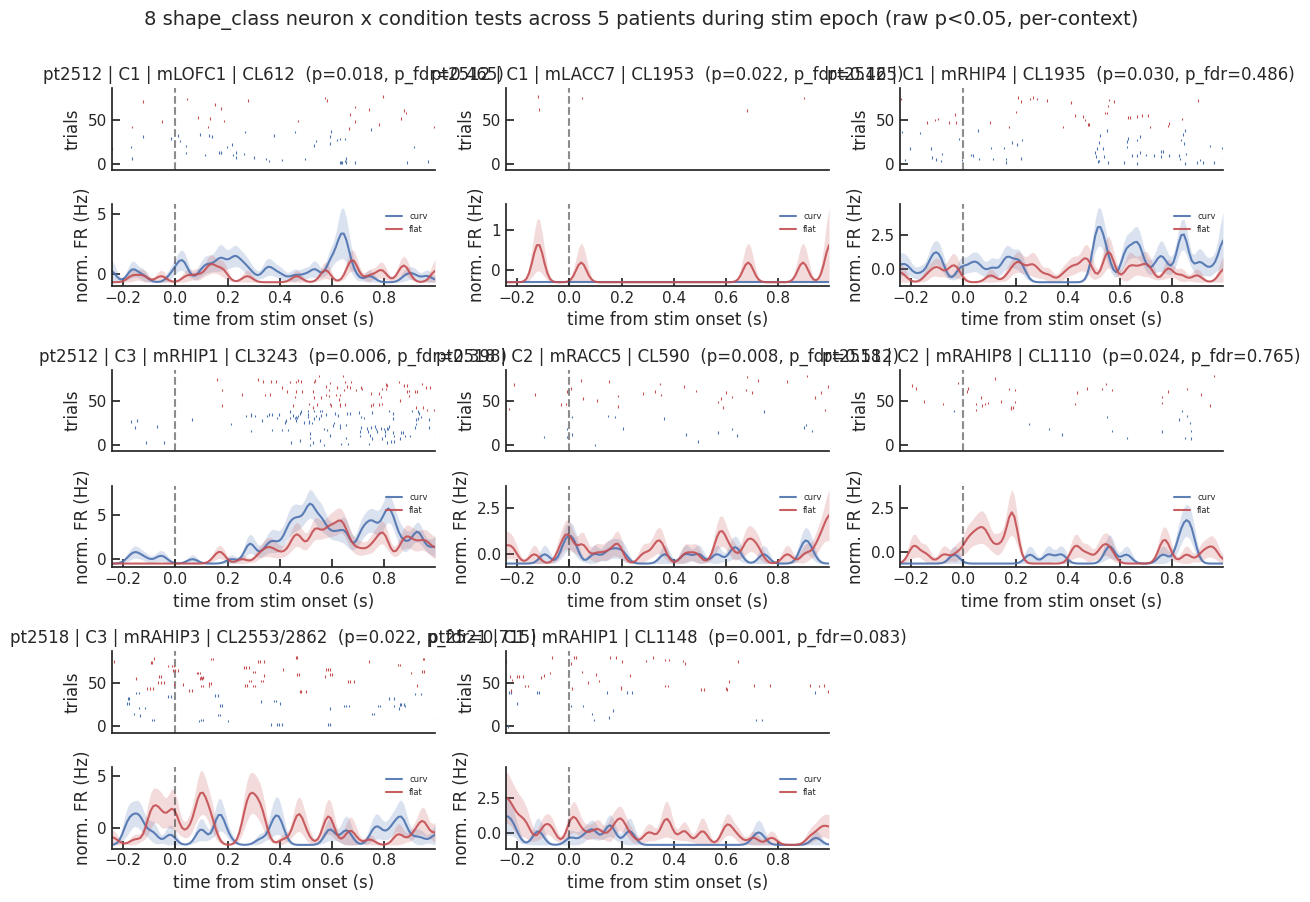

In [12]:
# Raster + PSTH for significant neurons across all patients, per-context
colors = ['b', 'r', 'g', 'k']

sig_df = all_neurs_percond_df[all_neurs_percond_df['pval'] < 0.05].copy().reset_index(drop=True)
print(f'Plotting {len(sig_df)} neuron x condition tests (raw p<0.05) across {sig_df["patient"].nunique()} patients')

normed_FRs = get_normed_FRs(FRs, base_FRs)  # stacked: cols already cover every patient

n_cols = 3
n_rows = max(1, int(np.ceil(len(sig_df) / n_cols)))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axs = np.array(axs).flatten()

for ax_idx, (_, row) in enumerate(sig_df.iterrows()):
    cond = row['context']
    col  = int(row['col_idx'])  # stacked column of this neuron
    cond_beh_trials_df = pt_beh_trials_dfs[row['patient']][pt_beh_trials_dfs[row['patient']]['context'] == cond]
    cont_trials = [cond_beh_trials_df[cond_beh_trials_df['shape'] == 'curv'].index,
                   cond_beh_trials_df[cond_beh_trials_df['shape'] == 'flat'].index]
    cont_labels = ['curv', 'flat']

    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(cont_labels)):
        raster_trial_list.extend(list(spikes[cont_trials[idx], col]))
        color_trial_list.extend([colors[idx]] * len(cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list,linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"pt{row['patient']} | {cond} | {row['region']} | CL{row['unitID']}  (p={row['pval']:.3f}, p_fdr={row['pval_fdr']:.3f})",ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for idx in range(len(cont_labels)):
        cont_data = normed_FRs[cont_trials[idx], col, :]
        mu     = cont_data.mean(axis=0)
        sderr  = cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
        ax_psth.plot(bin_centers, mu, color=colors[idx], alpha=0.9, label=cont_labels[idx])
        ax_psth.fill_between(bin_centers, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(bin_centers[0], bin_centers[-1]), ylabel='norm. FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

for ax_idx in range(len(sig_df), len(axs)):    axs[ax_idx].axis('off')

plt.suptitle(f'{len(sig_df)} {contrast} neuron x condition tests across {len(patients)} patients during {epoch} epoch (raw p<0.05, per-context)', y=1.0, fontsize=14)
plt.tight_layout(); plt.show()